Processing High-Dimensional Data for Machine Learning
When dealing with datasets with many columns (200+ features), proper feature processing is crucial to build effective machine learning models. Here's a comprehensive approach with a real-world example using the UCI ML Breast Cancer Wisconsin (Diagnostic) dataset (though it has only 30 features, the techniques scale to 200+).

Step-by-Step Approach

1. Load and Understand the Data

In [1]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, f_classif, RFE
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = load_breast_cancer()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target

print(f"Original shape: {df.shape}")
print("First 5 rows:")
print(df.head())

Original shape: (569, 31)
First 5 rows:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst

Motivation: Understanding the data structure is the first critical step. We need to know the number of features, their types, and the target distribution.

2. Data Preprocessing

In [3]:
# Check for missing values
print("\nMissing values per column:")
print(df.isnull().sum())

# Split data into features and target
X = df.drop('target', axis=1)
y = df['target']

# Scale the features (important for many feature selection methods)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print(f"\nTrain shape: {X_train.shape}, Test shape: {X_test.shape}")


Missing values per column:
mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
target                     0
dtype: int64

Train shape: (455, 30), Test shape: (114, 30)


Motivation: Scaling is essential as many feature selection methods are sensitive to feature scales. Train-test split ensures we evaluate feature selection properly.

3. Univariate Feature Selection


Top 10 features by univariate selection:
mean radius: 482.23
mean perimeter: 522.49
mean area: 423.65
mean concavity: 396.66
mean concave points: 695.18
worst radius: 645.35
worst perimeter: 681.26
worst area: 495.79
worst concavity: 331.33
worst concave points: 746.49


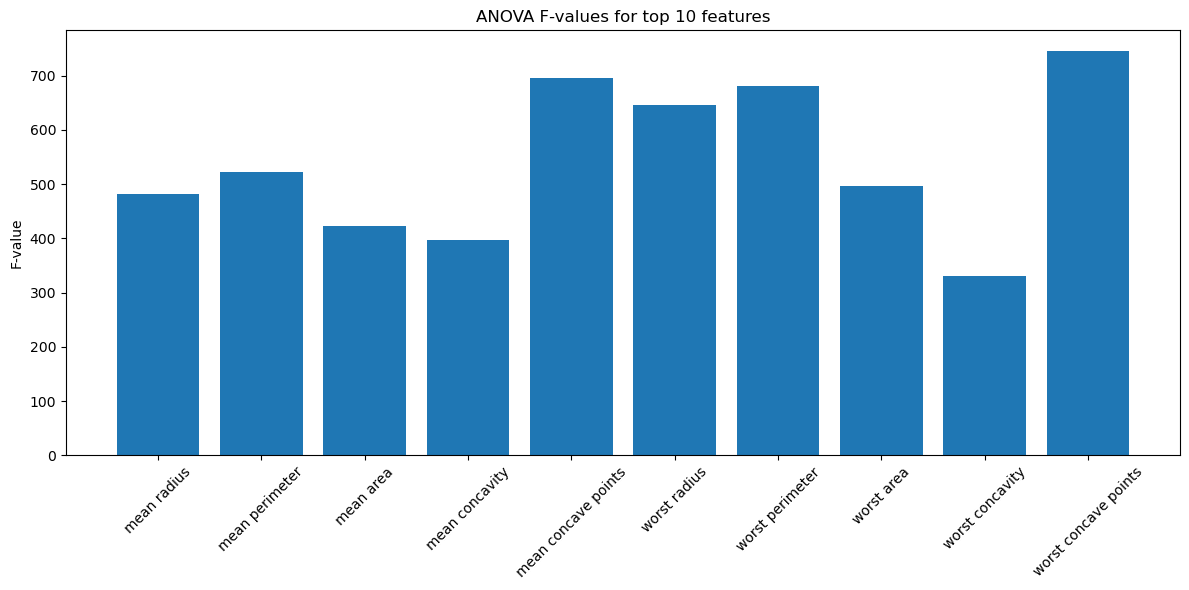

In [4]:
# Select top 10 features using ANOVA F-value
selector = SelectKBest(score_func=f_classif, k=10)
selector.fit(X_train, y_train)

# Get selected features
selected_features = X_train.columns[selector.get_support()]
scores = selector.scores_[selector.get_support()]

print("\nTop 10 features by univariate selection:")
for feature, score in zip(selected_features, scores):
    print(f"{feature}: {score:.2f}")

# Plot feature scores
plt.figure(figsize=(12, 6))
plt.bar(selected_features, scores)
plt.xticks(rotation=45)
plt.title("ANOVA F-values for top 10 features")
plt.ylabel("F-value")
plt.tight_layout()
plt.show()

Motivation: Univariate selection identifies features with the strongest individual relationships with the target, filtering out irrelevant ones.

4. Recursive Feature Elimination (RFE)


Top 10 features by RFE:
Index(['mean perimeter', 'mean area', 'mean concavity', 'mean concave points',
       'area error', 'worst radius', 'worst texture', 'worst perimeter',
       'worst area', 'worst concave points'],
      dtype='object')


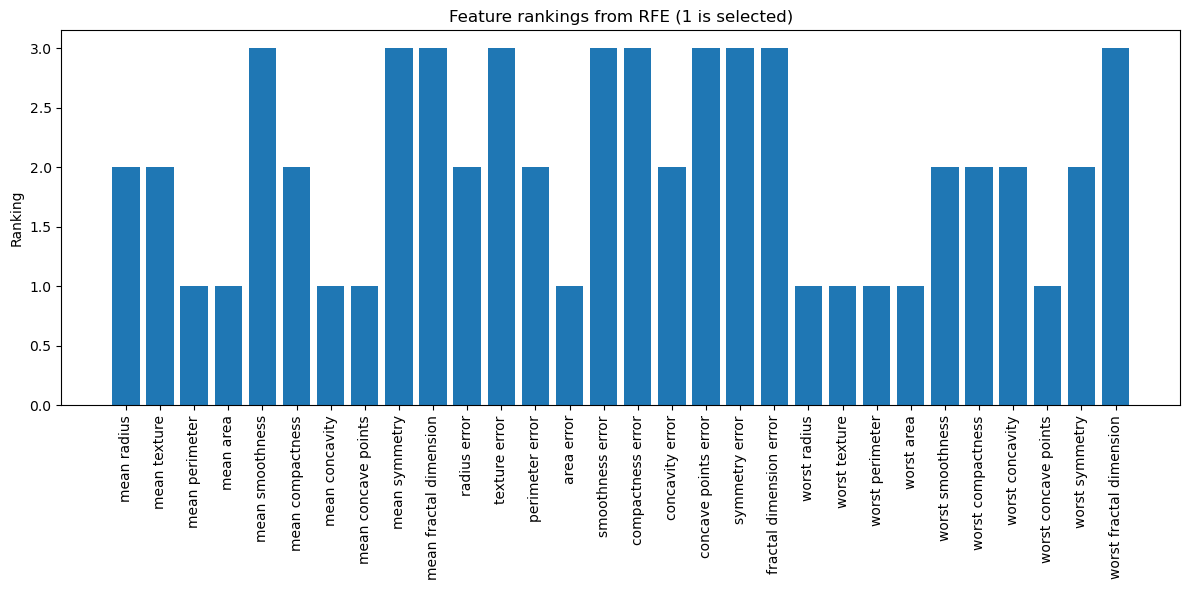

In [5]:
# Use RFE with Random Forest to select features
estimator = RandomForestClassifier(n_estimators=100, random_state=42)
rfe = RFE(estimator, n_features_to_select=10, step=10)
rfe.fit(X_train, y_train)

# Get selected features
rfe_features = X_train.columns[rfe.support_]
print("\nTop 10 features by RFE:")
print(rfe_features)

# Plot feature rankings
plt.figure(figsize=(12, 6))
plt.bar(X_train.columns, rfe.ranking_)
plt.xticks(rotation=90)
plt.title("Feature rankings from RFE (1 is selected)")
plt.ylabel("Ranking")
plt.tight_layout()
plt.show()

Motivation: RFE considers feature importance in the context of other features, providing a more sophisticated selection than univariate methods.

5. Feature Importance from Tree-Based Models


Feature ranking:
1. worst area: 0.1539
2. worst concave points: 0.1447
3. mean concave points: 0.1062
4. worst radius: 0.0780
5. mean concavity: 0.0680
6. worst perimeter: 0.0671
7. mean perimeter: 0.0533
8. mean radius: 0.0487
9. mean area: 0.0476
10. worst concavity: 0.0318


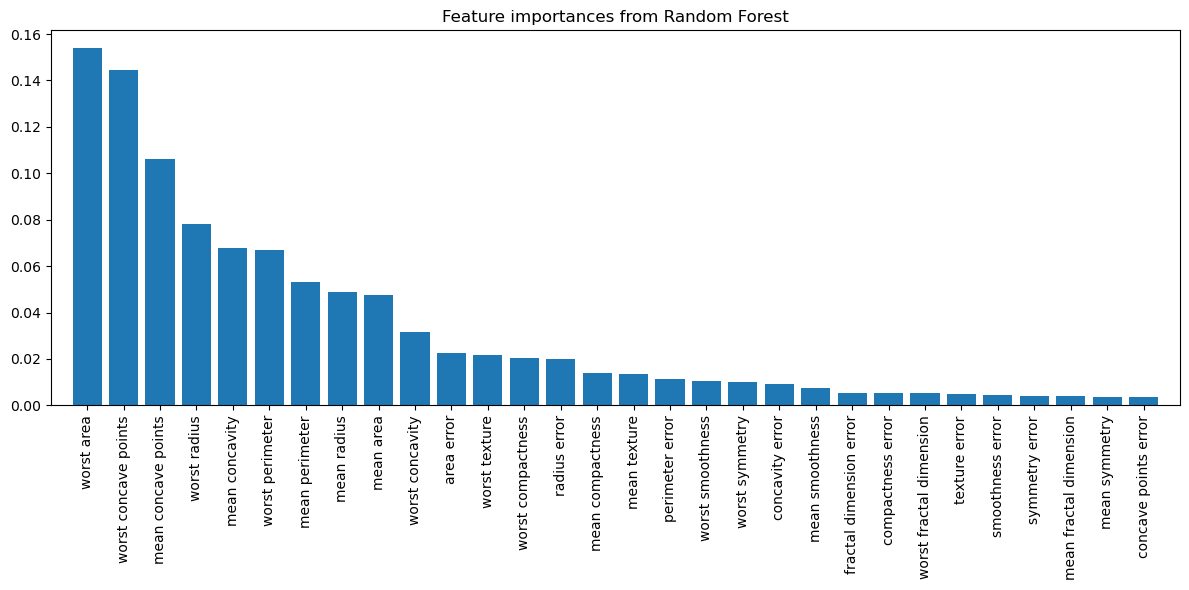

In [6]:
# Train Random Forest and get feature importances
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Get feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

print("\nFeature ranking:")
for i in range(10):
    print(f"{i+1}. {X_train.columns[indices[i]]}: {importances[indices[i]]:.4f}")

# Plot feature importances
plt.figure(figsize=(12, 6))
plt.title("Feature importances from Random Forest")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(range(X_train.shape[1]), X_train.columns[indices], rotation=90)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
plt.show()

Motivation: Tree-based models provide intrinsic feature importance measures that account for non-linear relationships and interactions.

6. Correlation Analysis

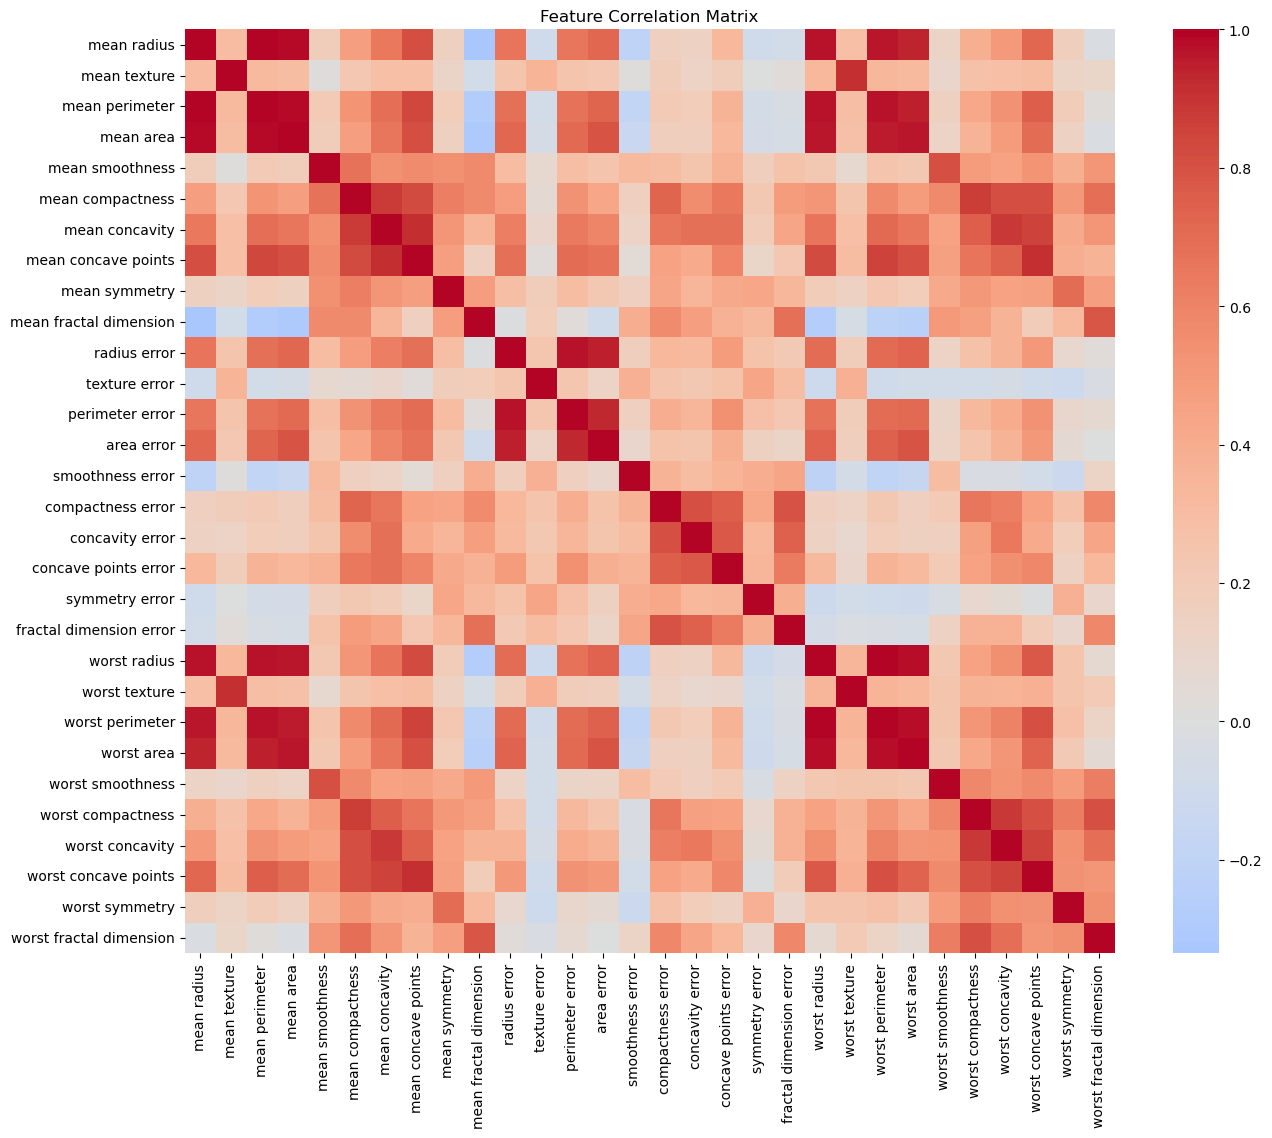


Highly correlated feature pairs (|corr| > 0.8):
mean radius - mean perimeter: 1.0
mean radius - mean area: 0.99
mean radius - mean concave points: 0.81
mean radius - worst radius: 0.97
mean radius - worst perimeter: 0.96
mean radius - worst area: 0.94
mean texture - worst texture: 0.91
mean perimeter - mean area: 0.99
mean perimeter - mean concave points: 0.84
mean perimeter - worst radius: 0.97
mean perimeter - worst perimeter: 0.97
mean perimeter - worst area: 0.94
mean area - mean concave points: 0.81
mean area - worst radius: 0.96
mean area - worst perimeter: 0.96
mean area - worst area: 0.96
mean smoothness - worst smoothness: 0.81
mean compactness - mean concavity: 0.88
mean compactness - mean concave points: 0.83
mean compactness - worst compactness: 0.87
mean compactness - worst concavity: 0.81
mean compactness - worst concave points: 0.82
mean concavity - mean concave points: 0.91
mean concavity - worst concavity: 0.88
mean concavity - worst concave points: 0.86
mean concave 

In [7]:
# Calculate correlation matrix
corr_matrix = X_train.corr()

# Plot correlation heatmap
plt.figure(figsize=(15, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0)
plt.title("Feature Correlation Matrix")
plt.show()

# Identify highly correlated features (absolute correlation > 0.8)
high_corr = np.where(np.abs(corr_matrix) > 0.8)
high_corr = [(corr_matrix.columns[x], corr_matrix.columns[y], round(corr_matrix.iloc[x,y], 2)) 
             for x, y in zip(*high_corr) if x != y and x < y]

print("\nHighly correlated feature pairs (|corr| > 0.8):")
for pair in high_corr:
    print(f"{pair[0]} - {pair[1]}: {pair[2]}")

Motivation: Highly correlated features provide redundant information and can be removed to reduce dimensionality without losing predictive power.

7. Principal Component Analysis (PCA)

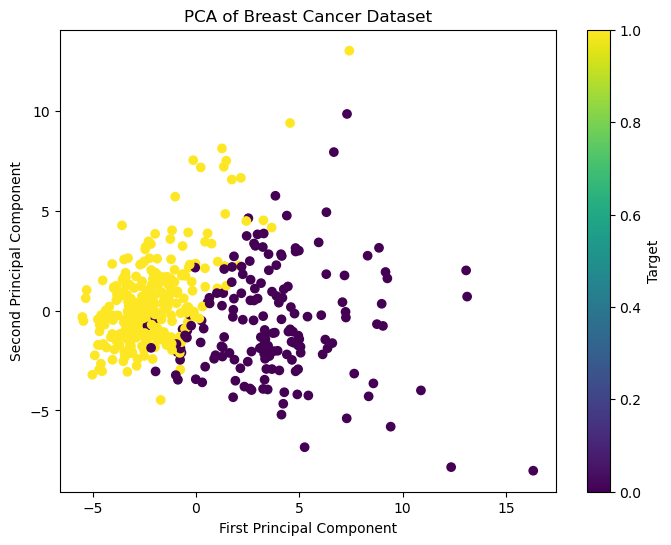

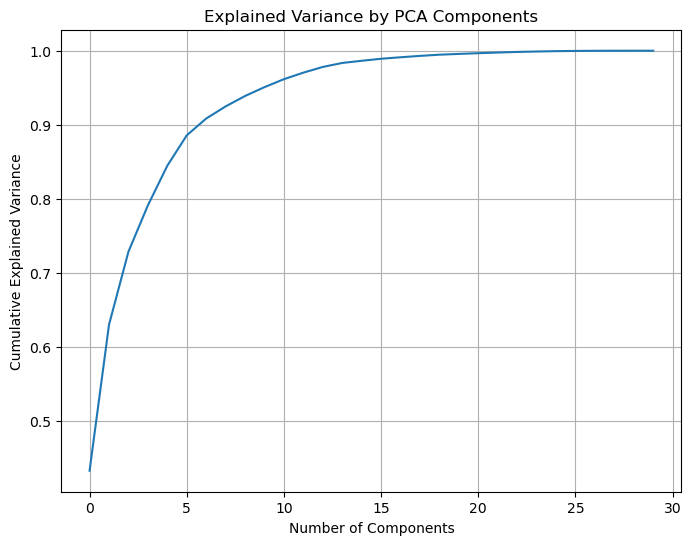


Number of components explaining 95% variance: 10


In [8]:
# Apply PCA to visualize feature space
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train)

# Plot PCA results
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=y_train, cmap='viridis')
plt.xlabel('First Principal Component')
plt.ylabel('Second Principal Component')
plt.title('PCA of Breast Cancer Dataset')
plt.colorbar(label='Target')
plt.show()

# Plot explained variance ratio
pca_full = PCA().fit(X_train)
plt.figure(figsize=(8, 6))
plt.plot(np.cumsum(pca_full.explained_variance_ratio_))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid()
plt.show()

# Find number of components explaining 95% variance
n_components = np.argmax(np.cumsum(pca_full.explained_variance_ratio_) >= 0.95) + 1
print(f"\nNumber of components explaining 95% variance: {n_components}")

Motivation: PCA helps understand the intrinsic dimensionality of the data and can be used for dimensionality reduction while preserving most of the variance.

8. Final Feature Selection Strategy

Based on all the above analyses, we can create a robust feature selection strategy:

In [9]:
# Combine results from different methods
from collections import defaultdict

feature_scores = defaultdict(int)

# Add scores from univariate selection
for feature, score in zip(selected_features, scores):
    feature_scores[feature] += score

# Add scores from RFE (ranking is inverse)
for feature, rank in zip(X_train.columns, rfe.ranking_):
    feature_scores[feature] += (len(X_train.columns) - rank)

# Add scores from feature importance
for feature, importance in zip(X_train.columns, importances):
    feature_scores[feature] += importance * 100  # scale to match other scores

# Normalize scores
max_score = max(feature_scores.values())
feature_scores = {k: v/max_score for k, v in feature_scores.items()}

# Get top 10 features based on combined scores
top_features = sorted(feature_scores.items(), key=lambda x: x[1], reverse=True)[:10]
top_feature_names = [f[0] for f in top_features]

print("\nTop 10 features based on combined selection:")
for feature, score in top_features:
    print(f"{feature}: {score:.4f}")

# Create final dataset with selected features
X_train_final = X_train[top_feature_names]
X_test_final = X_test[top_feature_names]

print(f"\nFinal training set shape: {X_train_final.shape}")


Top 10 features based on combined selection:
worst concave points: 1.0000
mean concave points: 0.9302
worst perimeter: 0.9076
worst radius: 0.8635
mean perimeter: 0.7049
worst area: 0.6838
mean radius: 0.6521
mean area: 0.5790
mean concavity: 0.5474
worst concavity: 0.4589

Final training set shape: (455, 10)


Motivation: Combining multiple feature selection methods provides a more robust selection than any single method alone.

9. Model Performance Comparison

In [10]:
from sklearn.metrics import accuracy_score, f1_score

# Baseline model with all features
rf_all = RandomForestClassifier(n_estimators=100, random_state=42)
rf_all.fit(X_train, y_train)
y_pred_all = rf_all.predict(X_test)
acc_all = accuracy_score(y_test, y_pred_all)
f1_all = f1_score(y_test, y_pred_all)

# Model with selected features
rf_selected = RandomForestClassifier(n_estimators=100, random_state=42)
rf_selected.fit(X_train_final, y_train)
y_pred_selected = rf_selected.predict(X_test_final)
acc_selected = accuracy_score(y_test, y_pred_selected)
f1_selected = f1_score(y_test, y_pred_selected)

print("\nModel Performance Comparison:")
print(f"All features - Accuracy: {acc_all:.4f}, F1: {f1_all:.4f}")
print(f"Selected features - Accuracy: {acc_selected:.4f}, F1: {f1_selected:.4f}")
print(f"Number of features reduced from {X_train.shape[1]} to {X_train_final.shape[1]} "
      f"({X_train_final.shape[1]/X_train.shape[1]:.1%} of original)")


Model Performance Comparison:
All features - Accuracy: 0.9649, F1: 0.9722
Selected features - Accuracy: 0.9561, F1: 0.9650
Number of features reduced from 30 to 10 (33.3% of original)


Motivation: Validating that our feature selection maintains or improves model performance while significantly reducing dimensionality.

Scaling to 200+ Features

For datasets with 200+ features, the same approach applies but with these adjustments:

Initial Filtering: Start with more aggressive univariate filtering (e.g., top 50-100 features) before applying more computationally expensive methods.
Correlation Analysis: Use approximate methods or sampling for correlation analysis with very large feature sets.
Dimensionality Reduction: Consider using more sophisticated techniques like t-SNE or UMAP for visualization when PCA doesn't separate classes well.
Feature Selection: Use model-based selection with L1 regularization (Lasso) for linear models, which automatically performs feature selection.
Parallel Processing: Many feature selection methods can be parallelized to handle large feature sets efficiently.
Here's an example of how you might modify the initial steps for 200+ features:

In [ ]:
# For 200+ features, start with more aggressive univariate filtering
selector_200 = SelectKBest(score_func=f_classif, k=50)  # Select top 50 first
X_train_filtered = selector_200.fit_transform(X_train, y_train)
selected_features_200 = X_train.columns[selector_200.get_support()]

# Then proceed with RFE or feature importance on this reduced set

This comprehensive approach ensures you select the most valuable features while maintaining model performance and interpretability, even with high-dimensional data.